In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\LENOVO\Downloads\upi-shield\data\processed\featured_transactions.csv')
print(f"Shape: {df.shape}")
print(f"Fraud cases: {df['isFraud'].sum():,}")

Shape: (2770409, 19)
Fraud cases: 8,213


In [2]:
# Features to use
FEATURES = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'hour', 'day', 'is_weekend', 'type_encoded',
    'balance_diff_orig', 'balance_diff_dest',
    'orig_balance_zero', 'amount_deviation'
]

X = df[FEATURES]
y = df['isFraud']

# Stratified split — preserves fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Fraud: {y_train.sum():,}")
print(f"Test:  {X_test.shape}  | Fraud: {y_test.sum():,}")

Train: (2216327, 13) | Fraud: 6,570
Test:  (554082, 13)  | Fraud: 1,643


In [3]:
# scale_pos_weight handles class imbalance
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.1f}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
print("XGBoost training complete")

scale_pos_weight: 336.3
XGBoost training complete


In [4]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.003,   # ~0.3% fraud rate in filtered data
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train)

# Convert: -1 (anomaly) → 1 (fraud), 1 (normal) → 0
iso_preds_test = (iso.predict(X_test) == -1).astype(int)
print("Isolation Forest training complete")
print(f"IF flagged as anomaly: {iso_preds_test.sum():,}")

Isolation Forest training complete
IF flagged as anomaly: 1,682


In [5]:
# XGBoost predictions
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_proba >= 0.5).astype(int)

print("=" * 50)
print("XGBoost")
print("=" * 50)
print(classification_report(y_test, xgb_preds, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC:  {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, xgb_proba):.4f}")

print()
print("=" * 50)
print("Isolation Forest")
print("=" * 50)
print(classification_report(y_test, iso_preds_test, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC:  {roc_auc_score(y_test, iso_preds_test):.4f}")

XGBoost
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    552439
       Fraud       0.55      0.98      0.71      1643

    accuracy                           1.00    554082
   macro avg       0.78      0.99      0.85    554082
weighted avg       1.00      1.00      1.00    554082

ROC-AUC:  0.9986
PR-AUC:   0.9713

Isolation Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    552439
       Fraud       0.18      0.19      0.18      1643

    accuracy                           1.00    554082
   macro avg       0.59      0.59      0.59    554082
weighted avg       1.00      1.00      1.00    554082

ROC-AUC:  0.5913


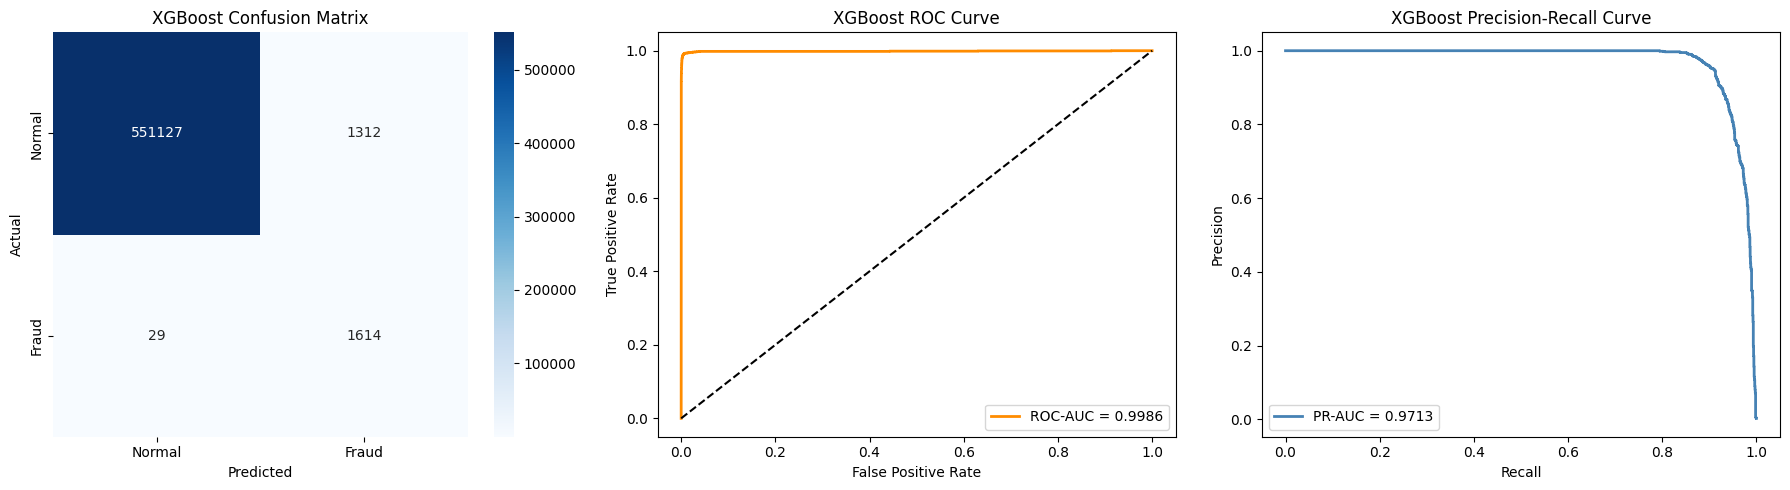

Saved.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
axes[0].set_title('XGBoost Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, xgb_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC-AUC = 0.9986')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('XGBoost ROC Curve')
axes[1].legend()

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, xgb_proba)
axes[2].plot(recall, precision, color='steelblue', lw=2,
             label=f'PR-AUC = 0.9713')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('XGBoost Precision-Recall Curve')
axes[2].legend()

plt.tight_layout()
import os
os.makedirs(r'C:\Users\LENOVO\Downloads\upi-shield\reports\figures', exist_ok=True)
plt.savefig(r'C:\Users\LENOVO\Downloads\upi-shield\reports\figures\day5_baseline_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

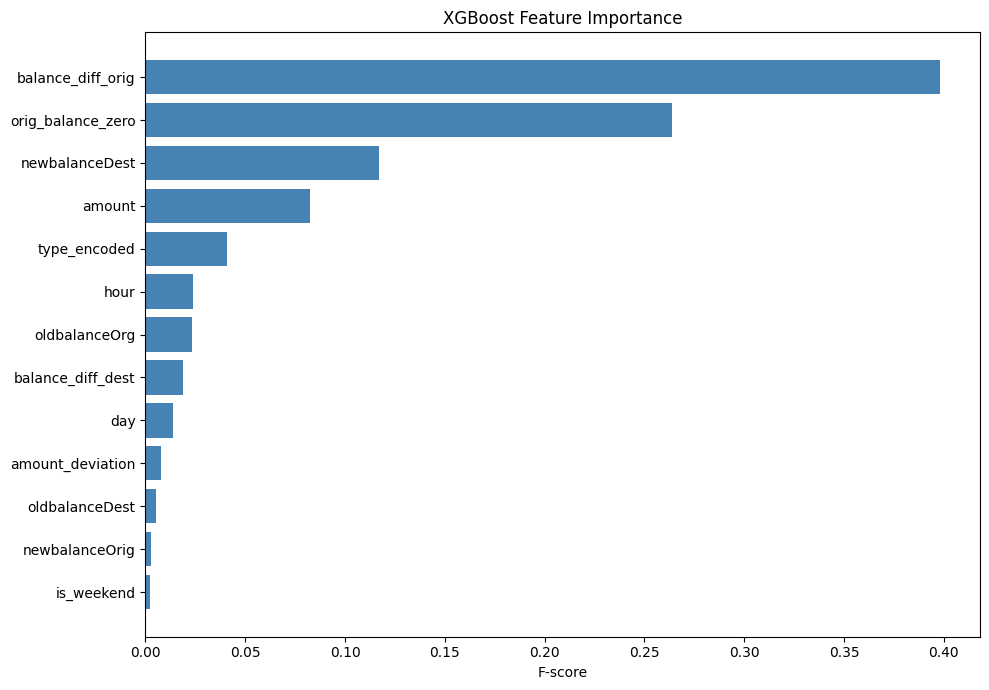

Saved.


In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=True)

ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('F-score')
plt.tight_layout()
plt.savefig(r'C:\Users\LENOVO\Downloads\upi-shield\reports\figures\day5_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [8]:
import subprocess
result = subprocess.run(
    ['python', r'C:\Users\LENOVO\Downloads\upi-shield\src\models.py'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

XGBoost trained.

XGBoost
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    552439
       Fraud       0.55      0.98      0.71      1643

    accuracy                           1.00    554082
   macro avg       0.78      0.99      0.85    554082
weighted avg       1.00      1.00      1.00    554082

ROC-AUC: 0.9986
PR-AUC:  0.9713
Saved: C:\Users\LENOVO\Downloads\upi-shield\models/xgboost_baseline.pkl
Isolation Forest trained.

Isolation Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    552439
       Fraud       0.18      0.19      0.18      1643

    accuracy                           1.00    554082
   macro avg       0.59      0.59      0.59    554082
weighted avg       1.00      1.00      1.00    554082

ROC-AUC: 0.5913
Saved: C:\Users\LENOVO\Downloads\upi-shield\models/isolation_forest.pkl


